# Directional Command Recognition in Sinhala-English Speech Using DistilHuBERT Acoustic Features

A robust pipeline for recognizing directional commands (forward, backward, left, right, stop) in code-mixed Sinhala-English speech using state-of-the-art acoustic feature extraction (DistilHuBERT).


![Pipeline](../pipeline.png)

### Project Overview

### 🛠 System Architecture & Model Pipeline

#### 1. Pipeline Visualization
Below is a descriptive overview of the end-to-end pipeline for directional command recognition from raw audio:

1. **Audio Processing:**
   - The system begins with raw audio input, which undergoes preprocessing steps such as silence trimming and volume normalization to ensure consistent quality.
2. **Feature Extraction:**
   - The preprocessed audio is passed through the **DistilHuBERT** model. Unlike ASR, which converts speech to text, this captures the raw acoustic and phonetic patterns of the speech directly into high-dimensional vectors (768-D).
   - We apply **Mean Pooling** to condense the temporal sequence of vectors into a single representative acoustic embedding for the entire audio clip.
3. **Classification:**
   - The acoustic embedding is fed into a lightweight PyTorch MLP classifier. This neural network processes the embedding through several layers, applying non-linear transformations and regularization, to predict the most likely directional command (Forward, Backward, Left, Right, or Stop).

This pipeline ensures that the system can robustly handle noisy, code-mixed speech and accurately map spoken commands to actionable directions without the overhead or errors of an intermediate ASR step.

#### 2. Core Model Concepts (Layer Format)

| **Component** | **Model/Layer Type** | **Key Function** |
| :--- | :--- | :--- |
| **Feature Extractor** | **DistilHuBERT** | Extracts high-dimensional acoustic features directly from raw audio waveforms, capturing phonetic nuances without needing transcription. |
| **Pooling** | **Mean Pooling** | Compresses the variable-length sequence of hidden states into a single 768-dimensional vector representing the entire utterance. |
| **Classifier** | **Input Layer** | Reduces the 768-D acoustic vector to a lower-dimensional space (128 units) and applies a ReLU activation for non-linearity. |
| **Classifier** | **Dropout** | Randomly deactivates 30% of neurons during training to prevent overfitting and improve generalization. |
| **Classifier** | **Hidden Layer** | Further compresses features to 64 units with ReLU activation, learning complex relationships between command types. |
| **Classifier** | **Output Layer** | Maps the learned features to one of the five directional command classes, producing the final prediction. |


### Environment Setup

In [4]:
!pip install transformers datasets torchaudio librosa tqdm matplotlib seaborn scikit-learn soundfile optuna


In [5]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import librosa.display
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## step 1: Data Acquisition & Preprocessing

*The foundation of the pipeline. Poor audio quality will cascade into the feature extractor and ruin the acoustic embeddings.*

1. **Dataset Compilation:** Gather `.wav` files for the 5 directional classes (forward, backward, left, right, stop) in both English, Sinhala, and code-mixed formats.
2. 💡 **Crucial Addition - Train/Val/Test Split:** You **must** split your raw audio files into Training (e.g., 70%), Validation (15%), and Test (15%) sets *before* doing any feature extraction. This prevents "data leakage" (accidentally testing on data the model has seen).
3. **Silence Trimming:** Remove dead air at the beginning and end of the audio clips.
4. 💡 **Crucial Addition - Volume Normalization:** Standardize the decibel level across all files. If some files are too quiet, the acoustic features might be poorly represented.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Clearing existing content in /content/drive...
Mounted at /content/drive


In [10]:
# 1.1 Dataset Compilation
DATA_DIR = "/content/drive/MyDrive/2nd Year Research Data/Directions"
LABELS = ["backward", "forward", "left", "right", "stop"]

data = []
for label in LABELS:
    path = os.path.join(DATA_DIR, label)
    if not os.path.exists(path):
        print(f"Warning: Path {path} does not exist.")
        continue
    files = glob.glob(os.path.join(path, "*.wav"))
    for f in files:
        data.append({"path": f, "label": label})

df = pd.DataFrame(data)
print(f"Total samples found: {len(df)}")

Total samples found: 380


### 1.3 Silence Trimming & Volume Normalization

In [11]:
import soundfile as sf
import os

def preprocess_audio(file_path):
    """Applies trimming and normalization to a single audio file."""
    y, sr = librosa.load(file_path, sr=16000)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    y_norm = librosa.util.normalize(y_trimmed)
    return y_norm, sr

if not df.empty:
    preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"
    os.makedirs(preprocessed_audio_dir, exist_ok=True)

    processed_paths = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing Audio"):
        filename = os.path.basename(row['path'])
        label_subdir = os.path.join(preprocessed_audio_dir, row['label'])
        os.makedirs(label_subdir, exist_ok=True)
        new_path = os.path.join(label_subdir, filename)

        # Check if the file already exists to avoid redundant processing
        if os.path.exists(new_path):
            processed_paths.append(new_path)
        else:
            try:
                y_proc, sr = preprocess_audio(row['path'])
                sf.write(new_path, y_proc, sr)
                processed_paths.append(new_path)
            except Exception as e:
                print(f" [Error] Failed to process {row['path']}: {e}")
                processed_paths.append(row['path']) # Fallback to original path if processing fails

    df['path'] = processed_paths
    print(f"Preprocessed paths updated for {len(df)} samples.")

Preprocessing Audio:   0%|          | 0/380 [00:00<?, ?it/s]

Preprocessed paths updated for 380 samples.


## step 2: Exploratory Data Analysis (EDA)

*Proving you understand the data before modeling it.*

1. **Class Imbalance Check:** Generate histograms to prove each of the 5 directions has roughly the same number of samples.
2. **Acoustic Visualization:** Generate and display Mel-spectrograms for a few samples to show the acoustic differences between English and Sinhala commands.
3. 💡 **Crucial Addition - Audio Length Distribution:** Plot a histogram of audio durations (e.g., most clips are 1.5 to 2.5 seconds). This justifies your real-time processing window later.

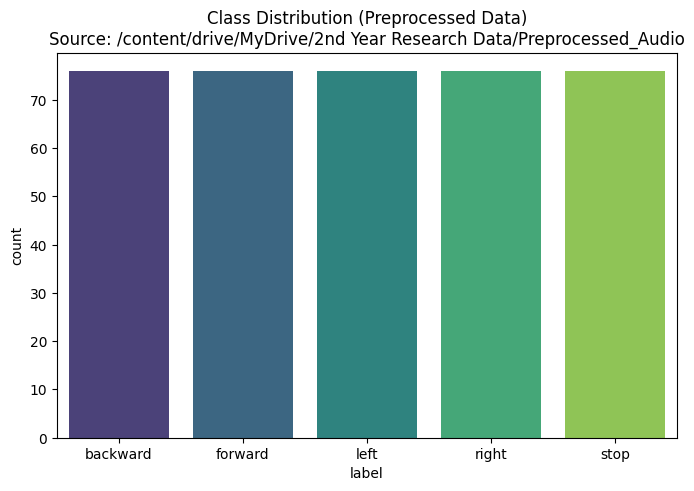

Total preprocessed samples found: 380


In [12]:
import glob

# Ensure we check the preprocessed directory
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

# Re-scan the preprocessed directory to ensure the plot reflects the actual processed files
preprocessed_data = []
for label in LABELS:
    label_path = os.path.join(preprocessed_audio_dir, label)
    if os.path.exists(label_path):
        files = glob.glob(os.path.join(label_path, "*.wav"))
        for f in files:
            preprocessed_data.append({"path": f, "label": label})

if preprocessed_data:
    df_plot = pd.DataFrame(preprocessed_data)
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_plot, x='label', palette='viridis')
    plt.title(f"Class Distribution (Preprocessed Data)\nSource: {preprocessed_audio_dir}")
    plt.show()
    print(f"Total preprocessed samples found: {len(df_plot)}")
else:
    print(f"[Error] No preprocessed audio found in {preprocessed_audio_dir}. Please run the preprocessing step first.")

Calculating durations... this may take a moment.


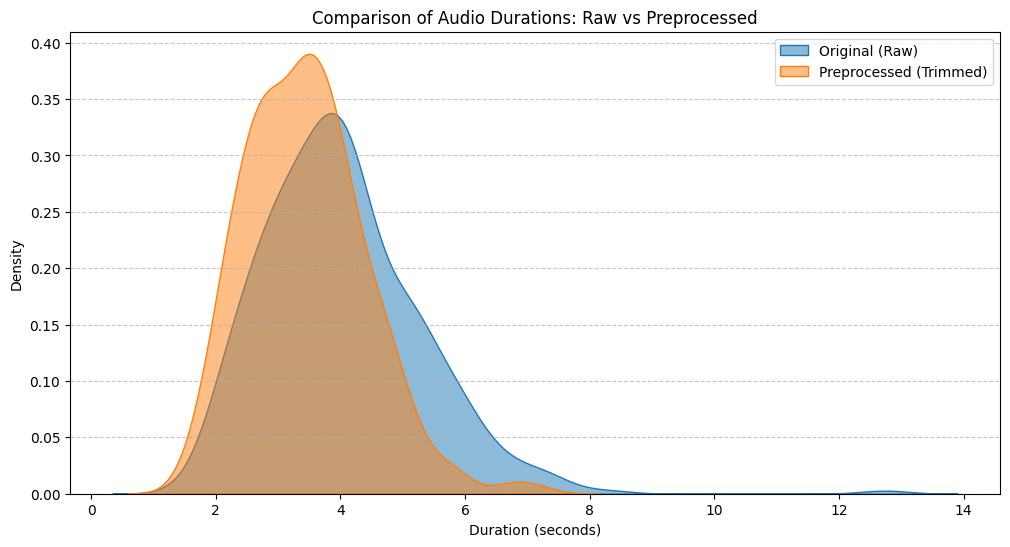


--- Duration Statistics Comparison ---
       Metric  Raw Data (s)  Preprocessed (s)
Mean Duration      4.021776           3.43834
 Min Duration      1.509250           1.47725
 Max Duration     12.736000           7.23200
Total Samples    377.000000         380.00000

Average reduction per file: 0.58s (due to silence trimming)


In [13]:
# 2.2 Audio Length Distribution Comparison (Before vs After Preprocessing)
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import numpy as np

raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"
LABELS = ["backward", "forward", "left", "right", "stop"]

def get_durations(base_dir):
    durations = []
    for label in LABELS:
        label_path = os.path.join(base_dir, label)
        if os.path.exists(label_path):
            files = glob.glob(os.path.join(label_path, "*.wav"))
            for f in files:
                try:
                    dur = librosa.get_duration(path=f)
                    durations.append(dur)
                except:
                    continue
    return durations

print("Calculating durations... this may take a moment.")
raw_durations = get_durations(raw_audio_dir)
proc_durations = get_durations(preprocessed_audio_dir)

if raw_durations and proc_durations:
    plt.figure(figsize=(12, 6))

    # Plotting comparison
    sns.kdeplot(raw_durations, label="Original (Raw)", fill=True, alpha=0.5)
    sns.kdeplot(proc_durations, label="Preprocessed (Trimmed)", fill=True, alpha=0.5)

    plt.title("Comparison of Audio Durations: Raw vs Preprocessed")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Display Stats
    stats_df = pd.DataFrame({
        "Metric": ["Mean Duration", "Min Duration", "Max Duration", "Total Samples"],
        "Raw Data (s)": [np.mean(raw_durations), np.min(raw_durations), np.max(raw_durations), len(raw_durations)],
        "Preprocessed (s)": [np.mean(proc_durations), np.min(proc_durations), np.max(proc_durations), len(proc_durations)]
    })

    print("\n--- Duration Statistics Comparison ---")
    print(stats_df.to_string(index=False))

    reduction = np.mean(raw_durations) - np.mean(proc_durations)
    print(f"\nAverage reduction per file: {reduction:.2f}s (due to silence trimming)")
else:
    print("[Error] Could not find audio in one of the directories. Please check your Drive paths.")

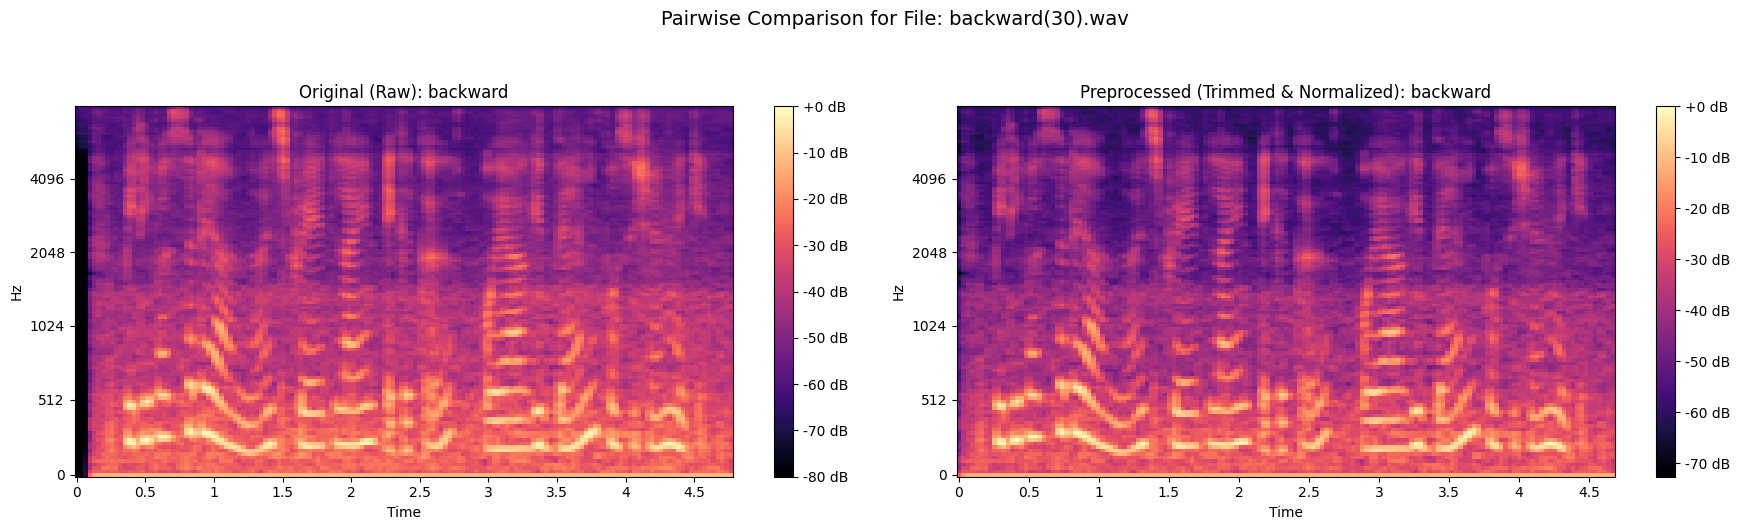

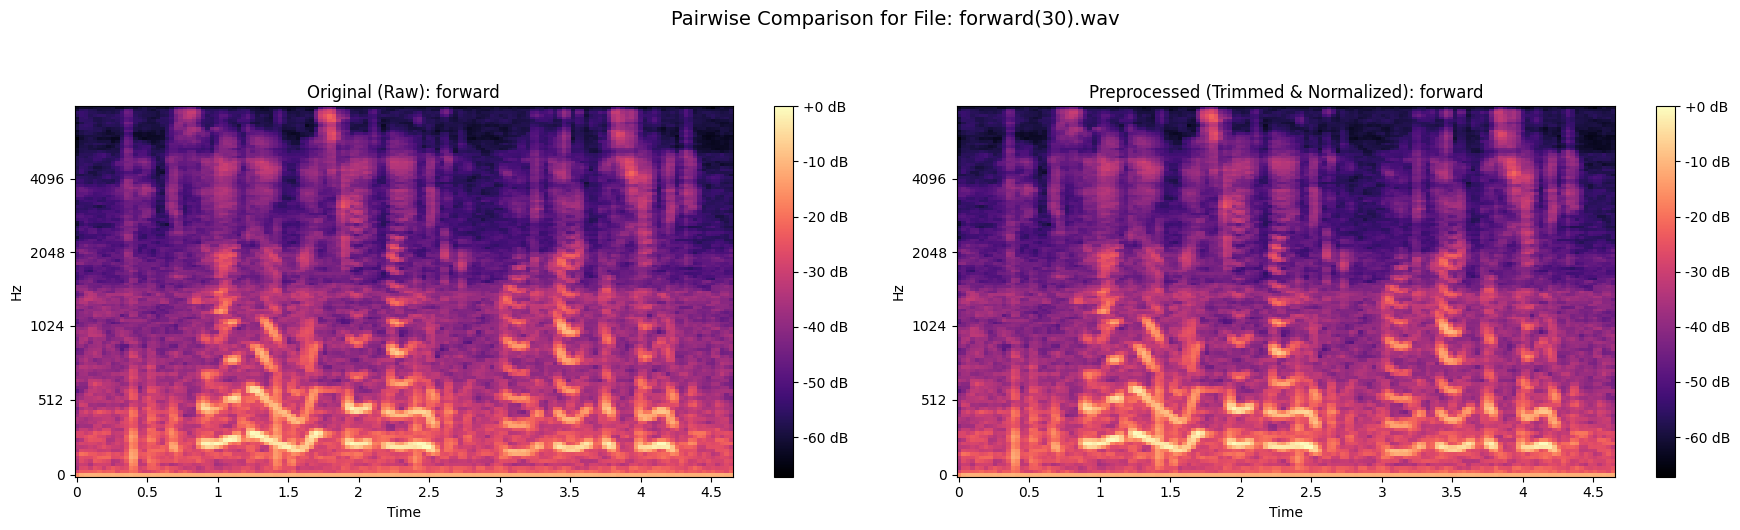

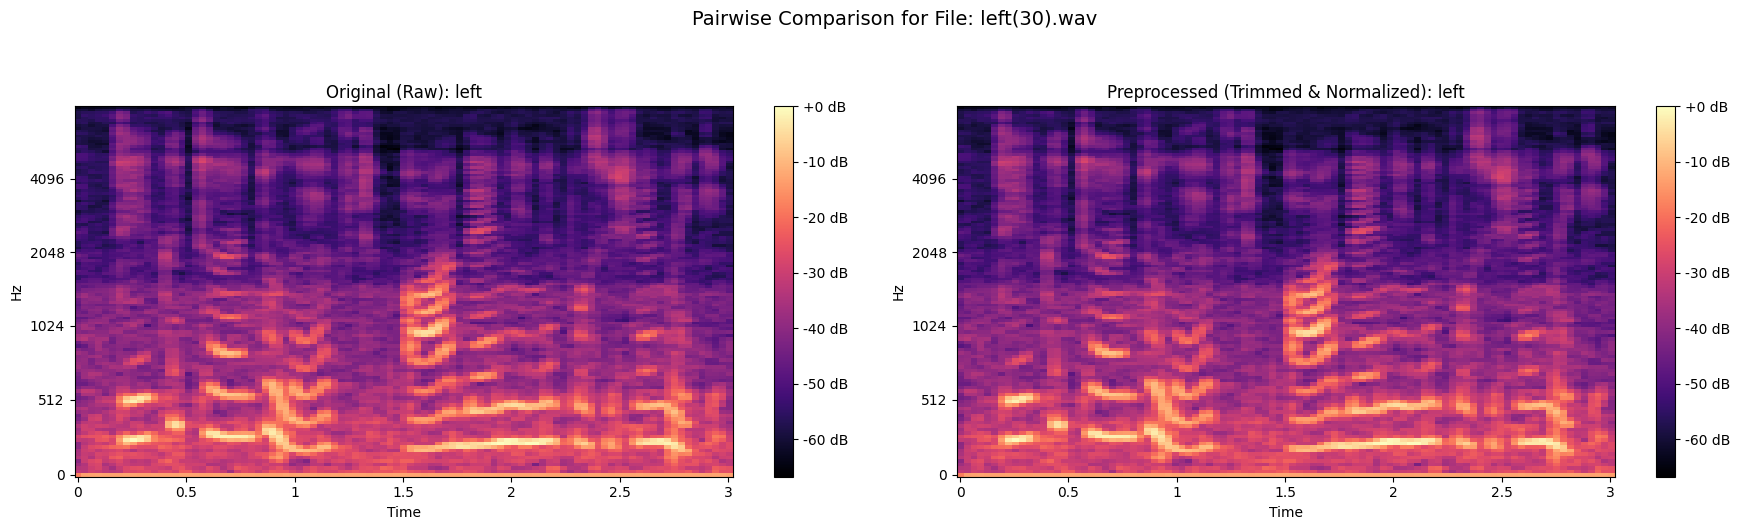

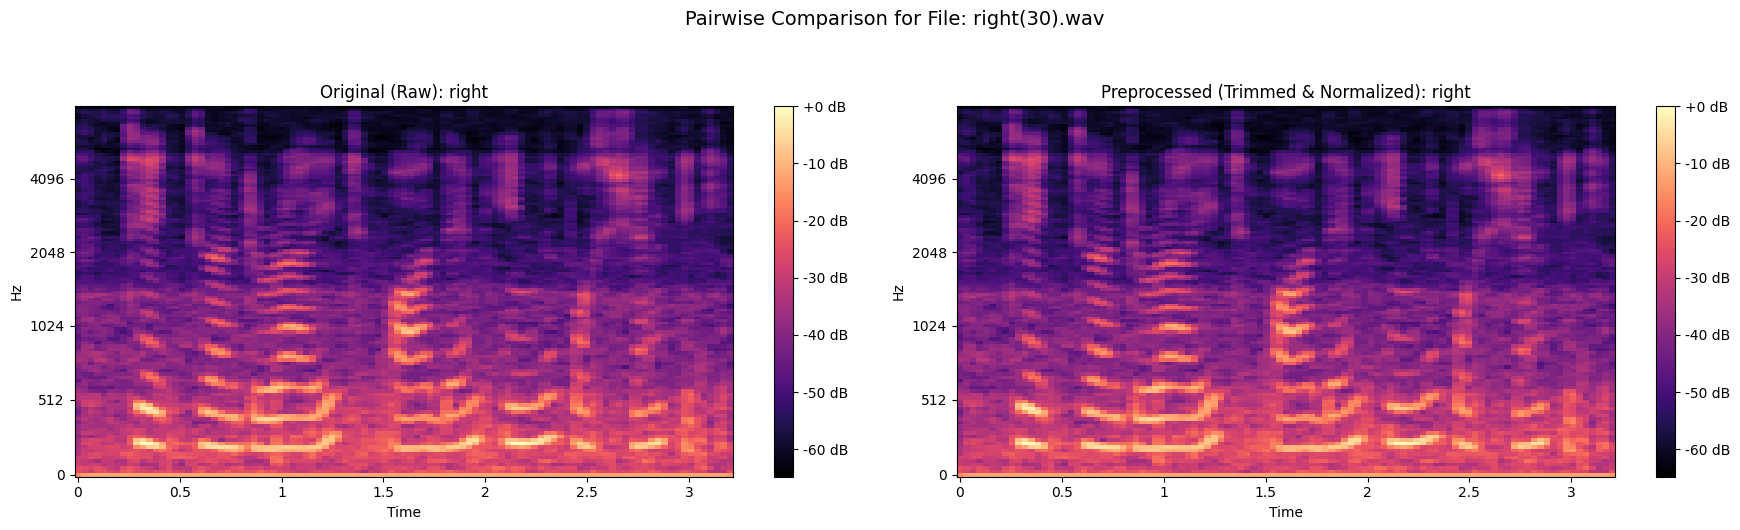

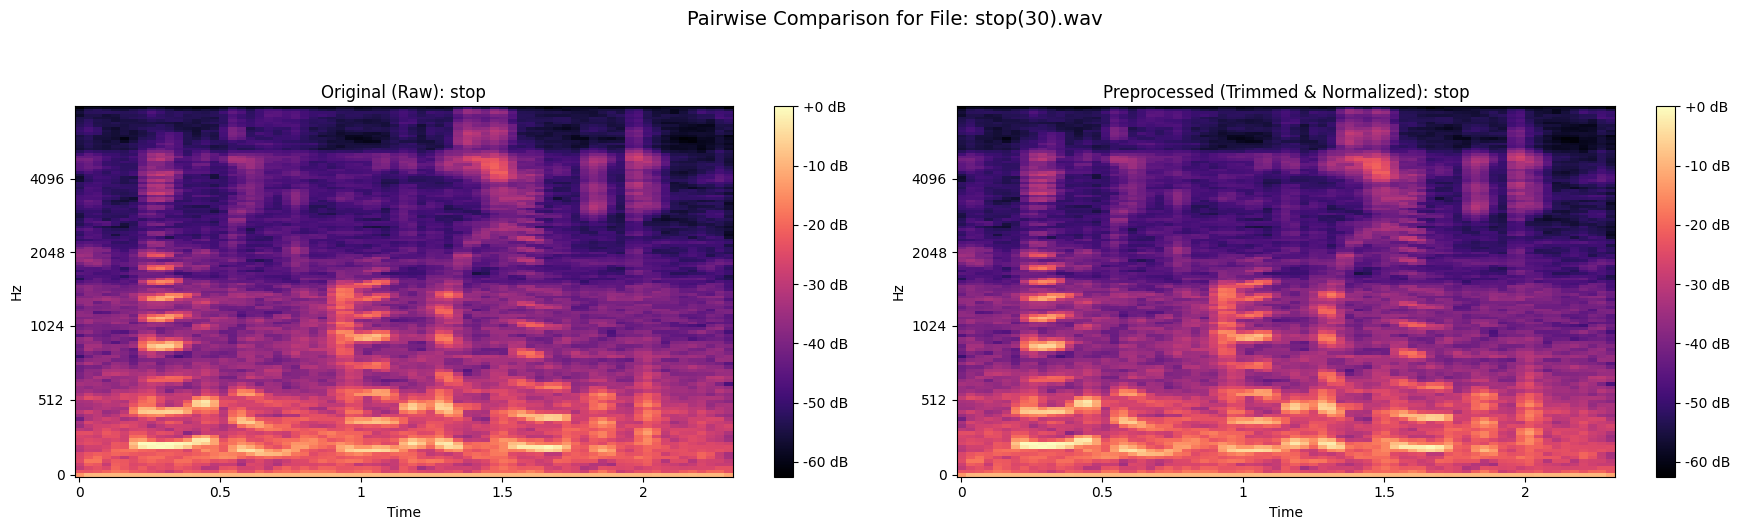

In [14]:
# 2.3 Acoustic Visualization: Before vs After Preprocessing (Pairwise Comparison)
import glob
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def compare_mel_spectrograms(raw_path, proc_path, label):
    # Adjusted to 1 row and 2 columns for horizontal positioning
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Raw Plot (Left)
    y_raw, sr = librosa.load(raw_path, sr=16000)
    S_raw = librosa.feature.melspectrogram(y=y_raw, sr=sr, n_mels=128)
    S_dB_raw = librosa.power_to_db(S_raw, ref=np.max)
    img1 = librosa.display.specshow(S_dB_raw, x_axis='time', y_axis='mel', sr=sr, ax=axes[0])
    axes[0].set_title(f"Original (Raw): {label}")
    fig.colorbar(img1, ax=axes[0], format='%+02.0f dB')

    # Preprocessed Plot (Right)
    y_proc, sr = librosa.load(proc_path, sr=16000)
    S_proc = librosa.feature.melspectrogram(y=y_proc, sr=sr, n_mels=128)
    S_dB_proc = librosa.power_to_db(S_proc, ref=np.max)
    img2 = librosa.display.specshow(S_dB_proc, x_axis='time', y_axis='mel', sr=sr, ax=axes[1])
    axes[1].set_title(f"Preprocessed (Trimmed & Normalized): {label}")
    fig.colorbar(img2, ax=axes[1], format='%+02.0f dB')

    plt.suptitle(f"Pairwise Comparison for File: {os.path.basename(raw_path)}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

# Visualize one sample for each label side-by-side
for label in LABELS:
    proc_label_path = os.path.join(preprocessed_audio_dir, label)
    if os.path.exists(proc_label_path):
        proc_files = glob.glob(os.path.join(proc_label_path, "*.wav"))
        if proc_files:
            filename = os.path.basename(proc_files[0])
            raw_file_path = os.path.join(raw_audio_dir, label, filename)

            if os.path.exists(raw_file_path):
                compare_mel_spectrograms(raw_file_path, proc_files[0], label)
            else:
                print(f"[Warn] Could not find raw counterpart for {filename}")

In [15]:
# 1.2 Train/Val/Test Split
if not df.empty:
    # Ensure we are using the preprocessed directory
    preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

    # Update the dataframe paths to point to the preprocessed versions if they exist
    def update_to_preprocessed_path(row):
        filename = os.path.basename(row['path'])
        new_path = os.path.join(preprocessed_audio_dir, row['label'], filename)
        return new_path if os.path.exists(new_path) else row['path']

    df['path'] = df.apply(update_to_preprocessed_path, axis=1)

    # Perform the split on the updated paths
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

    output_dir = "/content/drive/MyDrive/2nd Year Research Data/Data"
    os.makedirs(output_dir, exist_ok=True)
    train_df.to_csv(os.path.join(output_dir, 'train_df.csv'), index=False)
    val_df.to_csv(os.path.join(output_dir, 'val_df.csv'), index=False)
    test_df.to_csv(os.path.join(output_dir, 'test_df.csv'), index=False)

    print(f"Split complete using data from: {preprocessed_audio_dir}")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Split complete using data from: /content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio
Train: 266, Val: 57, Test: 57


## step 3: Feature Extraction (The NO-ASR Acoustic Bridge)

*Converting raw audio directly into high-dimensional acoustic representations using Self-Supervised Learning (SSL).*

1. **Acoustic Feature Extraction:** Pass the preprocessed 16kHz audio through the `ntu-spml/distilhubert` model. Unlike ASR, this captures the raw phonetic and rhythmic essence of the speech without converting it to text.
2. **Mean Pooling:** The model outputs a sequence of hidden state vectors. We apply mean pooling (averaging across the time dimension) to compress the variable-length sequence into a single, fixed-size 768-dimensional acoustic embedding.
3. **Tensor Conversion:** Ensure the resulting embeddings are PyTorch Tensors ready for the MLP classifier.
4. 💡 **Crucial Addition - Vector Caching:** Save these final tensors to your hard drive using `torch.save(tensor, 'train_features.pt')`. This avoids re-running the heavy SSL model during every training iteration.
5. 💡 **Crucial Addition - t-SNE / PCA Visualization:** Reduce the 768D acoustic vectors to 2D using t-SNE. This visually demonstrates if DistilHuBERT naturally clusters similar directional commands together, even without textual labels.

--- Initializing Models (Device: cuda) ---


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/94.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/49 [00:00<?, ?it/s]

...

Successfully saved features to /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs/train_features.pt

Processing val_features.pt sequentially...


  0%|          | 0/57 [00:00<?, ?it/s]

Successfully saved features to /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs/val_features.pt

Processing test_features.pt sequentially...


  0%|          | 0/57 [00:00<?, ?it/s]

Successfully saved features to /content/drive/MyDrive/2nd Year Research Data/feature extractor outputs/test_features.pt

Generating Acoustic Visualization...


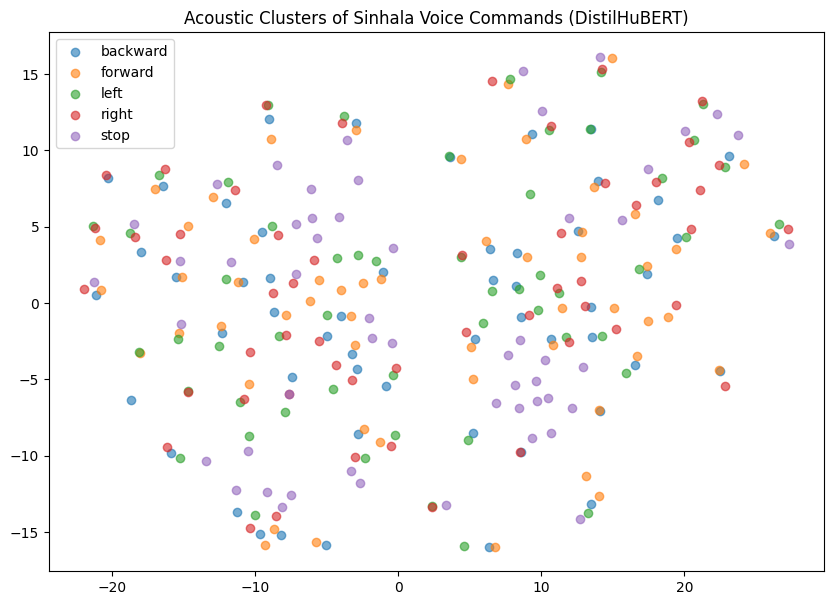

In [16]:
from transformers import AutoFeatureExtractor, HubertModel
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from typing import Optional
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa

# --- Safety Check ---
if 'DEVICE' not in locals(): DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'LABELS' not in locals(): LABELS = ["backward", "forward", "left", "right", "stop"]

model_id = "ntu-spml/distilhubert"

print(f"--- Initializing Models (Device: {DEVICE}) ---")
try:
    feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)
    hubert_model = HubertModel.from_pretrained(model_id).to(DEVICE)
    hubert_model.eval() # Set to evaluation mode
    print("Models loaded successfully.")
except Exception as e:
    print(f"Error loading models: {e}")
    feature_extractor, hubert_model = None, None

def load_audio(path: str, sr: int = 16000) -> Optional[np.ndarray]:
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)
        return audio.astype(np.float32)
    except Exception as e:
        print(f" [Warn] Could not load '{path}': {e}")
        return None

def extract_features_sequential(df, filename):
    feat_dir  = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
    save_path = os.path.join(feat_dir, filename)
    os.makedirs(feat_dir, exist_ok=True)

    all_embeddings, all_labels = [], []
    print(f"\nProcessing {filename} sequentially...")

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        audio = load_audio(row['path'])
        if audio is None: continue

        try:
            # Prepare input for the model
            inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt").to(DEVICE)

            with torch.no_grad():
                outputs = hubert_model(**inputs)
                # Apply mean pooling over the sequence dimension (dim=1)
                # outputs.last_hidden_state shape: [1, sequence_length, 768]
                embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()

            all_embeddings.append(embedding)
            all_labels.append(LABELS.index(row['label']))

        except Exception as e:
            print(f" [Error] Failed on {row['path']}: {e}")

    if all_embeddings:
        features = {
            "embeddings": torch.tensor(np.array(all_embeddings), dtype=torch.float32),
            "labels": torch.tensor(all_labels, dtype=torch.long)
        }
        torch.save(features, save_path)
        print(f"Successfully saved features to {save_path}")
        return features
    return None

# --- Main Execution ---
if 'train_df' in locals() and hubert_model:
    train_features = extract_features_sequential(train_df, "train_features.pt")
    val_features   = extract_features_sequential(val_df,   "val_features.pt")
    test_features  = extract_features_sequential(test_df,  "test_features.pt")

    if train_features:
        print("\nGenerating Acoustic Visualization...")
        n_samples = len(train_features['embeddings'])
        # Perplexity adjustment for small datasets
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, n_samples-1))
        projs = tsne.fit_transform(train_features['embeddings'].numpy())

        plt.figure(figsize=(10, 7))
        for i, label in enumerate(LABELS):
            idx = np.where(train_features['labels'].numpy() == i)
            plt.scatter(projs[idx, 0], projs[idx, 1], label=label, alpha=0.6)

        plt.title("Acoustic Clusters of Sinhala Voice Commands (DistilHuBERT)")
        plt.legend()
        plt.show()

## step 4: Model Creation & Training (PyTorch)

*Building the lightweight classifier with architectures inspired by low-resource speech research.*

### 4.1 Layer-by-Layer Explanation of the MLP (768D Vector)
The custom network is designed to process DistilHuBERT acoustic features using robust classification practices found in the literature:

1. **Layer 1: The Input Layer**
   - **Size:** 768 neurons.
   - **Function:** Receives the 768-dimensional dense vectors from the `ntu-spml/distilhubert` model.

2. **Layer 2: Hidden Dense Layer 1**
   - **Size:** 128 neurons.
   - **Activation:** `ReLU` (Rectified Linear Unit). Transforms negative values to zero to learn complex, non-linear relationships (as seen in Paper 2).
   - **Function:** Maps 768 inputs to 128 features, identifying patterns like "specific values in the 768D vector that correlate with 'Forward' commands."

3. **Layer 3: Regularization (Dropout)**
   - **Parameter:** `p = 0.3`.
   - **Function:** Randomly deactivates 30% of neurons during training to prevent overfitting, forcing the model to learn distributed patterns rather than memorizing noise.

4. **Layer 4: Hidden Dense Layer 2**
   - **Size:** 64 neurons.
   - **Activation:** `ReLU`.
   - **Function:** Compresses 128 patterns into 64 highly refined features for final decision-making.

5. **Layer 5: Output Layer**
   - **Size:** 5 neurons (Forward, Backward, Left, Right, Stop).
   - **Activation:** `Softmax`.
   - **Function:** Normalizes raw scores into a probability distribution (summing to 100%), providing confidence scores for the UI.

### 4.2 Hyperparameters for Model Fitting
These parameters are validated by literature for low-resource tasks:

*   **Optimizer:** `Adam` (LR=0.001). Efficiently adapts learning rates; commonly used in XLSR pretraining.
*   **Loss Function:** `Categorical Cross-Entropy`. Penalizes confident incorrect predictions.
*   **Batch Size:** 16 or 32. Ideal for low-RAM environments and stable weight updates.
*   **Epochs:** 30 to 50. Ensures the model fully observes the dataset patterns (Paper 2 benchmark).

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
import os
import pandas as pd

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean', label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, hidden_dropout=0.40):
        super(CommandClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Dropout(0.20),
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(hidden_dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.network(x)

# --- Path Setup ---
feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"
os.makedirs(training_output_dir, exist_ok=True)

train_path = os.path.join(feature_input_dir, "train_features.pt")
val_path   = os.path.join(feature_input_dir, "val_features.pt")
best_model_file = os.path.join(training_output_dir, "best_model.pth")
best_history_file = os.path.join(training_output_dir, "best_training_history.csv")

if os.path.exists(train_path) and os.path.exists(val_path):
    train_data = torch.load(train_path)
    val_data   = torch.load(val_path)
    X_train, y_train = train_data['embeddings'], train_data['labels']
    X_val, y_val     = val_data['embeddings'], val_data['labels']

    # [UPDATED] Lowered to 32 for higher-resolution gradient steps
    BATCH_SIZE = 32
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    model = CommandClassifier(hidden_dropout=0.4).to(DEVICE)
    criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)

    # [UPDATED] More frequent, smoother decay for the final walk down the loss slope
    scheduler = StepLR(optimizer, step_size=10, gamma=0.7)

    EPOCHS = 100
    patience = 15
    best_val_loss = float('inf')
    trigger_times = 0
    history_list = []

    print(f"--- Starting Single Normal Training on {DEVICE} ---")
    for epoch in range(EPOCHS):
        model.train()
        train_loss, correct = 0, 0
        for inputs, labels_batch in train_loader:
            inputs, labels_batch = inputs.to(DEVICE), labels_batch.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels_batch)
            loss.backward()

            # [NEW] Gradient Clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels_batch).sum().item()

        train_acc = correct / len(X_train)

        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for inputs, labels_batch in val_loader:
                inputs, labels_batch = inputs.to(DEVICE), labels_batch.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels_batch).sum().item()

        val_acc = correct / len(X_val)
        val_loss_epoch = val_loss / len(val_loader)
        scheduler.step()

        metrics = {
            "epoch": epoch + 1, "train_loss": train_loss / len(train_loader),
            "val_loss": val_loss_epoch, "train_acc": train_acc,
            "val_acc": val_acc, "lr": optimizer.param_groups[0]['lr']
        }
        history_list.append(metrics)

        pd.DataFrame(history_list).to_csv(os.path.join(training_output_dir, "training_history.csv"), index=False)

        print(f"Epoch {epoch+1:02d} | Loss: {metrics['train_loss']:.3f} | Val Loss: {metrics['val_loss']:.3f} | Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

        # Only save the "best" history when a new peak is hit
        if val_loss_epoch < best_val_loss:
            best_val_loss = val_loss_epoch
            trigger_times = 0
            torch.save(model.state_dict(), best_model_file)
            pd.DataFrame(history_list).to_csv(best_history_file, index=False)
            print("   -> Saved new best model and learning curve history.")
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("[INFO] Early stopping triggered!")
                break

--- Starting Single Normal Training on cuda ---
Epoch 01 | Loss: 0.974 | Val Loss: 0.843 | Acc: 0.316 | Val Acc: 0.456
   -> Saved new best model and learning curve history.
Epoch 02 | Loss: 0.747 | Val Loss: 0.648 | Acc: 0.556 | Val Acc: 0.719
   -> Saved new best model and learning curve history.
Epoch 03 | Loss: 0.590 | Val Loss: 0.502 | Acc: 0.669 | Val Acc: 0.737
   -> Saved new best model and learning curve history.
Epoch 04 | Loss: 0.464 | Val Loss: 0.407 | Acc: 0.733 | Val Acc: 0.789
   -> Saved new best model and learning curve history.
Epoch 05 | Loss: 0.386 | Val Loss: 0.334 | Acc: 0.752 | Val Acc: 0.842
   -> Saved new best model and learning curve history.
Epoch 06 | Loss: 0.305 | Val Loss: 0.275 | Acc: 0.872 | Val Acc: 0.912
   -> Saved new best model and learning curve history.
Epoch 07 | Loss: 0.285 | Val Loss: 0.262 | Acc: 0.823 | Val Acc: 0.860
   -> Saved new best model and learning curve history.
Epoch 08 | Loss: 0.240 | Val Loss: 0.231 | Acc: 0.891 | Val Acc: 0.930

## step 5: Deep Learning Evaluations

*Generating the standard ML metrics required to prove efficacy.*

1. **Learning Curves:** Plot the Epoch vs. Accuracy curve and Epoch vs. Loss curve.
2. 💡 **Crucial Addition - Confusion Matrix:** Pass your strictly isolated **Test Set** through the trained model. Plot a Confusion Matrix to see exactly where the model fails.
3. 💡 **Crucial Addition - Classification Report:** Calculate the Precision, Recall, and F1-Score for each of the 5 classes using the Test Set.

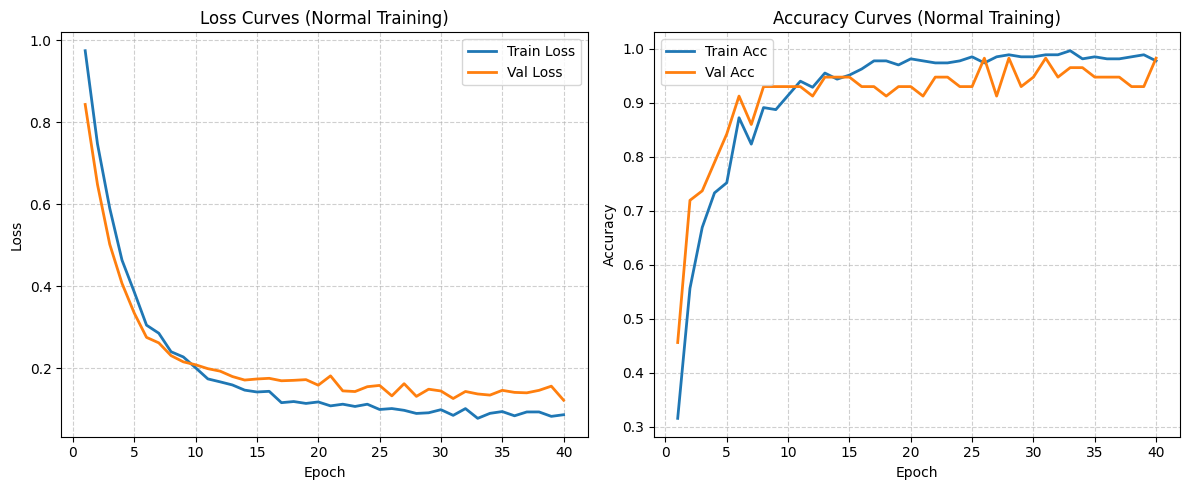


 🎯 FINAL MODEL EVALUATION (Blind Test Set)

Classification Report:
              precision    recall  f1-score   support

    backward       0.91      0.83      0.87        12
     forward       1.00      0.82      0.90        11
        left       0.71      0.91      0.80        11
       right       0.85      0.92      0.88        12
        stop       0.90      0.82      0.86        11

    accuracy                           0.86        57
   macro avg       0.87      0.86      0.86        57
weighted avg       0.87      0.86      0.86        57



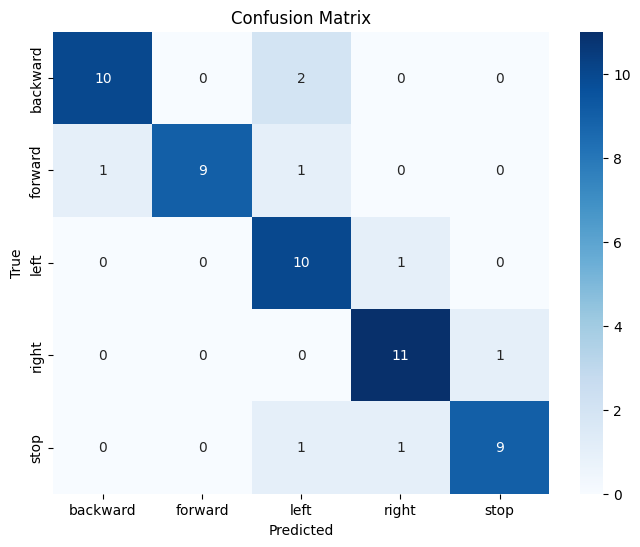

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# --- Path Setup ---
feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"

best_history_file   = os.path.join(training_output_dir, "best_training_history.csv")
best_model_path     = os.path.join(training_output_dir, "best_model.pth")
test_path           = os.path.join(feature_input_dir,   "test_features.pt")
LABELS = ['backward', 'forward', 'left', 'right', 'stop']
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================================
# 1. LEARNING CURVES
# =====================================================================
if os.path.exists(best_history_file):
    history_df = pd.read_csv(best_history_file)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss', linewidth=2)
    plt.title('Loss Curves (Normal Training)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(history_df['epoch'], history_df['train_acc'], label='Train Acc', linewidth=2)
    plt.plot(history_df['epoch'], history_df['val_acc'],   label='Val Acc', linewidth=2)
    plt.title('Accuracy Curves (Normal Training)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Could not find {best_history_file}.")

# =====================================================================
# 2. MODEL EVALUATION
# =====================================================================
class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5):
        super(CommandClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Dropout(0.20),
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.network(x)

if os.path.exists(test_path) and os.path.exists(best_model_path):
    print("\n" + "="*60)
    print(" 🎯 FINAL MODEL EVALUATION (Blind Test Set)")
    print("="*60)

    test_features = torch.load(test_path)
    model = CommandClassifier().to(DEVICE)
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True), strict=False)
    model.eval()

    test_loader = DataLoader(TensorDataset(test_features['embeddings'], test_features['labels']), batch_size=16)

    all_preds, all_true = [], []
    with torch.no_grad():
        for inputs, labels_batch in test_loader:
            inputs  = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(labels_batch.numpy())

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds, target_names=LABELS))

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

####The Optuna Hyperparameter Tuner

Hyperparameters for Model Fitting
These parameters are validated by literature for low-resource tasks:

Optimizer: Adam (LR=0.001). Efficiently adapts learning rates; commonly used in XLSR pretraining.
Loss Function: Categorical Cross-Entropy. Penalizes confident incorrect predictions.
Batch Size: 16 or 32. Ideal for low-RAM environments and stable weight updates.
Epochs: 30 to 50. Ensures the model fully observes the dataset patterns (Paper 2 benchmark).

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, TensorDataset
import os
import pandas as pd
import optuna
import warnings
warnings.filterwarnings("ignore")

# --- 1. Custom Loss & Architecture ---

# [HIDDEN] Focal Loss implementation commented out per request
# class FocalLoss(nn.Module):
#     def __init__(self, gamma=2.0, reduction='mean', label_smoothing=0.1):
#         super(FocalLoss, self).__init__()
#         self.gamma = gamma
#         self.reduction = reduction
#         self.label_smoothing = label_smoothing
#
#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
#         pt = torch.exp(-ce_loss)
#         focal_loss = ((1 - pt) ** self.gamma) * ce_loss
#         if self.reduction == 'mean': return focal_loss.mean()
#         return focal_loss.sum()

# --- Dynamic Architecture ---
class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, num_layers=1, hidden_size=256, dropout=0.3):
        super(CommandClassifier, self).__init__()
        layers = []
        layers.append(nn.LayerNorm(input_dim))

        current_dim = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(current_dim, hidden_size))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_size

        layers.append(nn.Linear(current_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x): return self.network(x)

# --- 2. Data Loading ---
feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"
os.makedirs(training_output_dir, exist_ok=True)

train_data = torch.load(os.path.join(feature_input_dir, "train_features.pt"))
val_data   = torch.load(os.path.join(feature_input_dir, "val_features.pt"))
X_train, y_train = train_data['embeddings'], train_data['labels']
X_val, y_val     = val_data['embeddings'], val_data['labels']

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

global_best_acc = 0.0

def objective(trial):
    global global_best_acc

    # --- 1. The Smoothed Search Space ---
    num_layers = trial.suggest_int("num_layers", 1, 2)
    hidden_size = trial.suggest_categorical("hidden_size", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.05, 0.35)
    lr = trial.suggest_float("lr", 1e-5, 8e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)

    # [REMOVED] gamma = trial.suggest_categorical("gamma", [1.0, 2.0, 3.0]) - No longer needed for Cross Entropy

    model = CommandClassifier(
        input_dim=768,
        num_classes=5,
        num_layers=num_layers,
        hidden_size=hidden_size,
        dropout=dropout
    ).to(DEVICE)

    # [UPDATED] Using standard Cross Entropy Loss instead of Focal Loss
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    EPOCHS = 75
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history_list = []
    best_trial_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        train_loss, correct = 0, 0
        for inputs, labels_batch in train_loader:
            inputs, labels_batch = inputs.to(DEVICE), labels_batch.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels_batch)
            loss.backward()

            # Gradient Clipping: Prevents violent spikes early in training
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels_batch).sum().item()

        train_acc = correct / len(X_train)

        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for inputs, labels_batch in val_loader:
                inputs, labels_batch = inputs.to(DEVICE), labels_batch.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels_batch)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == labels_batch).sum().item()

        val_acc = correct / len(X_val)
        scheduler.step()

        metrics = {
            "epoch": epoch + 1, "train_loss": train_loss / len(train_loader),
            "val_loss": val_loss / len(val_loader), "train_acc": train_acc, "val_acc": val_acc
        }
        history_list.append(metrics)

        best_trial_acc = max(best_trial_acc, val_acc)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if val_acc > global_best_acc:
            global_best_acc = val_acc
            torch.save(model.state_dict(), os.path.join(training_output_dir, "absolute_best_model.pth"))
            pd.DataFrame(history_list).to_csv(os.path.join(training_output_dir, "best_training_history.csv"), index=False)

    return best_trial_acc

# --- 4. Run the Optuna Study ---
print(f"[INFO] Starting Optuna Hyperparameter Optimization on {DEVICE}...")
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=75)

print("\n" + "="*40)
print(" OPTUNA SEARCH COMPLETE")
print("="*40)
print(f"Absolute Best Validation Accuracy: {study.best_value*100:.2f}%")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

study.trials_dataframe().to_csv(os.path.join(training_output_dir, "optuna_full_report.csv"), index=False)

[I 2026-05-27 05:02:54,771] A new study created in memory with name: no-name-4103fad9-e982-4210-bfcd-925b59da0f86


[INFO] Starting Optuna Hyperparameter Optimization on cuda...


[I 2026-05-27 05:02:58,292] Trial 0 finished with value: 0.9298245614035088 and parameters: {'num_layers': 2, 'hidden_size': 256, 'dropout': 0.33936413554263334, 'lr': 0.00013901179474965639, 'weight_decay': 0.000760106499720037}. Best is trial 0 with value: 0.9298245614035088.
[I 2026-05-27 05:03:00,462] Trial 1 finished with value: 0.8596491228070176 and parameters: {'num_layers': 2, 'hidden_size': 128, 'dropout': 0.28430644253297555, 'lr': 7.67992118515851e-05, 'weight_decay': 0.006772949749076415}. Best is trial 0 with value: 0.9298245614035088.
[I 2026-05-27 05:03:02,833] Trial 2 finished with value: 0.6842105263157895 and parameters: {'num_layers': 2, 'hidden_size': 128, 'dropout': 0.06420209698005766, 'lr': 1.8174577999091415e-05, 'weight_decay': 0.00034021544687829684}. Best is trial 0 with value: 0.9298245614035088.
[I 2026-05-27 05:03:05,538] Trial 3 finished with value: 0.6842105263157895 and parameters: {'num_layers': 2, 'hidden_size': 512, 'dropout': 0.1821532839023567, 'l


 OPTUNA SEARCH COMPLETE
Absolute Best Validation Accuracy: 100.00%
Best Hyperparameters:
    num_layers: 1
    hidden_size: 256
    dropout: 0.12531523768758437
    lr: 0.0006514929293671386
    weight_decay: 0.003927313227845695


## step 5: Deep Learning Evaluations on Hyperparameter tuning

*Generating the standard ML metrics required to prove efficacy.*

1. **Learning Curves:** Plot the Epoch vs. Accuracy curve and Epoch vs. Loss curve.
2. 💡 **Crucial Addition - Confusion Matrix:** Pass your strictly isolated **Test Set** through the trained model. Plot a Confusion Matrix to see exactly where the model fails.
3. 💡 **Crucial Addition - Classification Report:** Calculate the Precision, Recall, and F1-Score for each of the 5 classes using the Test Set.


 🔎 OPTUNA HYPERPARAMETER SEARCH ANALYSIS

Top 5 Discovered Configurations:
 number    value  params_lr  params_weight_decay  params_num_layers  params_hidden_size  params_dropout
      6 1.000000   0.000651             0.003927                  1                 256        0.125315
     43 1.000000   0.000773             0.002127                  2                 512        0.075056
     45 1.000000   0.000666             0.001679                  2                 512        0.106263
     10 0.982456   0.000661             0.009155                  1                 256        0.118503
      8 0.982456   0.000217             0.000152                  2                 512        0.349570


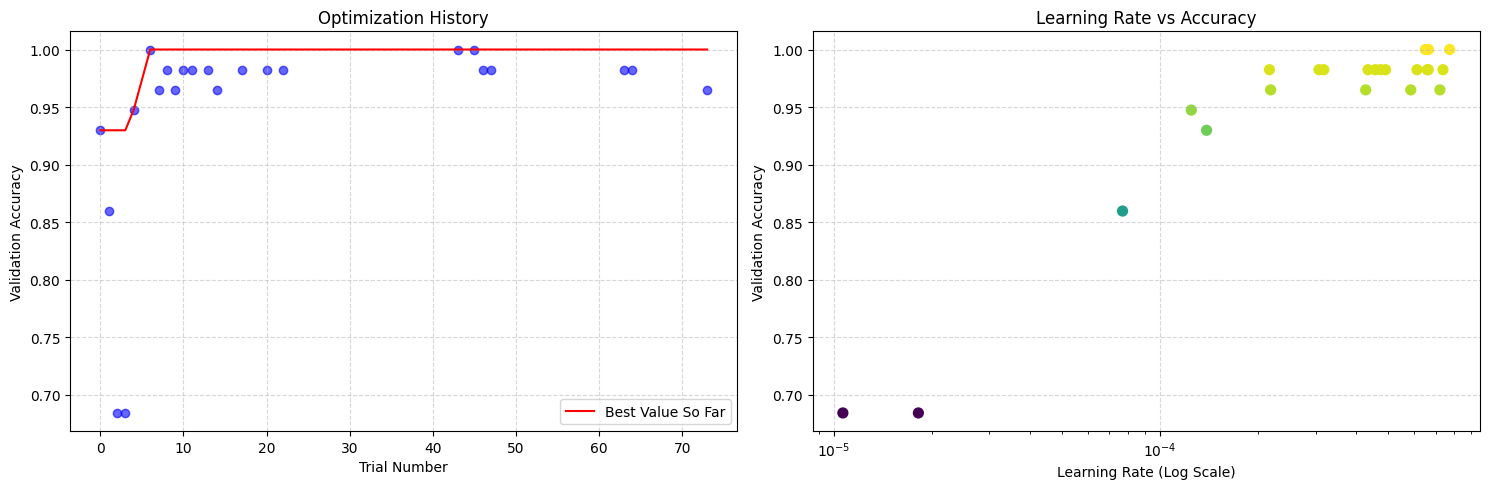

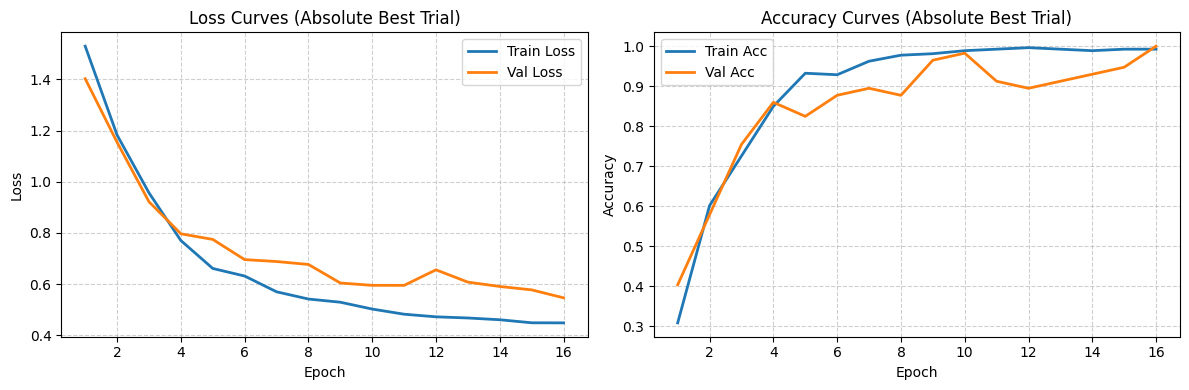


 🎯 ABSOLUTE BEST MODEL EVALUATION (Blind Test Set)

Classification Report:
              precision    recall  f1-score   support

    backward       0.83      0.83      0.83        12
     forward       1.00      0.73      0.84        11
        left       0.77      0.91      0.83        11
       right       0.85      0.92      0.88        12
        stop       0.82      0.82      0.82        11

    accuracy                           0.84        57
   macro avg       0.85      0.84      0.84        57
weighted avg       0.85      0.84      0.84        57



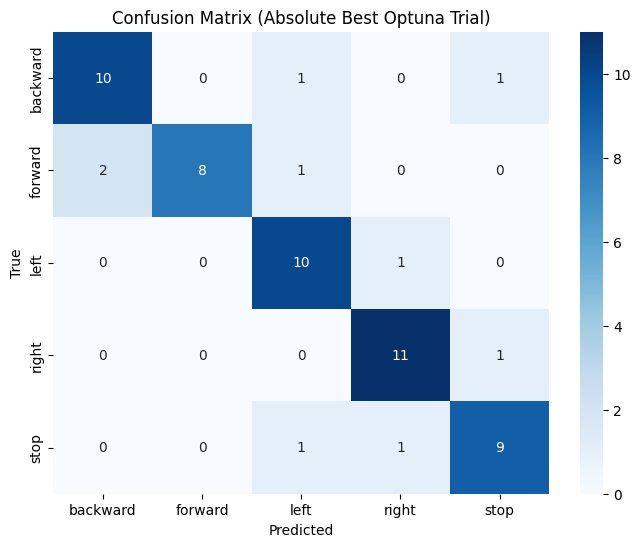

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# --- Path Setup ---
feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"

optuna_report_file  = os.path.join(training_output_dir, "optuna_full_report.csv")
best_history_file   = os.path.join(training_output_dir, "best_training_history.csv")
best_model_path     = os.path.join(training_output_dir, "absolute_best_model.pth")
test_path           = os.path.join(feature_input_dir,   "test_features.pt")

LABELS = ['backward', 'forward', 'left', 'right', 'stop']
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================================
# 1. OPTUNA HYPERPARAMETER LANDSCAPE VISUALIZATION
# =====================================================================
if os.path.exists(optuna_report_file):
    print("\n" + "="*60)
    print(" 🔎 OPTUNA HYPERPARAMETER SEARCH ANALYSIS")
    print("="*60)

    df = pd.read_csv(optuna_report_file)
    # Filter out pruned/failed trials
    df_complete = df[df['state'] == 'COMPLETE']

    # Print Top 5 Configurations (Removed 'params_gamma')
    print("\nTop 5 Discovered Configurations:")
    top_5 = df_complete.sort_values(by='value', ascending=False).head(5)
    print(top_5[['number', 'value', 'params_lr', 'params_weight_decay', 'params_num_layers', 'params_hidden_size', 'params_dropout']].to_string(index=False))

    # Plot 1: Optimization History
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1) # Changed to 1,2,1 since one plot is removed
    plt.scatter(df_complete['number'], df_complete['value'], c='blue', alpha=0.6)
    plt.plot(df_complete['number'], df_complete['value'].cummax(), c='red', label='Best Value So Far')
    plt.title('Optimization History')
    plt.xlabel('Trial Number')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Learning Rate vs Accuracy
    plt.subplot(1, 2, 2) # Changed to 1,2,2
    plt.scatter(df_complete['params_lr'], df_complete['value'], c=df_complete['value'], cmap='viridis', s=50)
    plt.xscale('log')
    plt.title('Learning Rate vs Accuracy')
    plt.xlabel('Learning Rate (Log Scale)')
    plt.ylabel('Validation Accuracy')
    plt.grid(True, linestyle='--', alpha=0.5)

    # Removed Plot 3: Focal Loss Gamma vs Accuracy as gamma parameter is no longer used.

    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Could not find {optuna_report_file}.")

# =====================================================================
# 2. LEARNING CURVES OF THE ABSOLUTE BEST MODEL
# =====================================================================
if os.path.exists(best_history_file):
    history_df = pd.read_csv(best_history_file)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss', linewidth=2)
    plt.title('Loss Curves (Absolute Best Trial)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(history_df['epoch'], history_df['train_acc'], label='Train Acc', linewidth=2)
    plt.plot(history_df['epoch'], history_df['val_acc'],   label='Val Acc', linewidth=2)
    plt.title('Accuracy Curves (Absolute Best Trial)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. ABSOLUTE BEST MODEL EVALUATION
# =====================================================================
# Retrieve best hyperparameters from the Optuna report
# Also handle case where report might not exist or be empty
best_num_layers = 1 # Default values
best_hidden_size = 256
best_dropout = 0.3

if os.path.exists(optuna_report_file):
    df_optuna = pd.read_csv(optuna_report_file)
    if not df_optuna.empty and 'value' in df_optuna.columns:
        best_trial = df_optuna.loc[df_optuna['value'].idxmax()]
        if 'params_num_layers' in best_trial: best_num_layers = int(best_trial['params_num_layers'])
        if 'params_hidden_size' in best_trial: best_hidden_size = int(best_trial['params_hidden_size'])
        if 'params_dropout' in best_trial: best_dropout = float(best_trial['params_dropout'])
    else:
        print("[WARN] Optuna report found but is empty or malformed. Using default model architecture for evaluation.")
else:
    print("[WARN] Optuna report not found. Using default model architecture for evaluation.")

class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, num_layers=1, hidden_size=256, dropout=0.3):
        super(CommandClassifier, self).__init__()
        layers = []
        layers.append(nn.LayerNorm(input_dim))

        current_dim = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(current_dim, hidden_size))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_size

        layers.append(nn.Linear(current_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x): return self.network(x)

if os.path.exists(test_path) and os.path.exists(best_model_path):
    print("\n" + "="*60)
    print(" 🎯 ABSOLUTE BEST MODEL EVALUATION (Blind Test Set)")
    print("="*60)

    test_features = torch.load(test_path)

    # Instantiate the model with the best hyperparameters from Optuna
    model = CommandClassifier(
        num_layers=best_num_layers,
        hidden_size=best_hidden_size,
        dropout=best_dropout
    ).to(DEVICE)

    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
    model.eval()

    test_loader = DataLoader(TensorDataset(test_features['embeddings'], test_features['labels']), batch_size=16)

    all_preds, all_true = [], []
    with torch.no_grad():
        for inputs, labels_batch in test_loader:
            inputs  = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(labels_batch.numpy())

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds, target_names=LABELS))

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Absolute Best Optuna Trial)')
    plt.show()

## step 6: Predictions (The Sanity Check)

*Proving the system works on unseen data before integrating a microphone.*

1. **Isolated Inference Script:** Write a script that randomly selects one audio file from the Test Set.
2. **Full Pass-Through:** Run that single audio file through the entire pipeline (DistilHuBERT → Loaded `.pth` Model).
3. **Result Output:** Print the Softmax probabilities alongside the True Label vs. Predicted Label to visually confirm success.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import os
import random
from pathlib import Path
from transformers import Wav2Vec2Processor, HubertModel
import warnings

warnings.filterwarnings("ignore")

# --- 1. System Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS = ["backward", "forward", "left", "right", "stop"]

print("[INFO] Loading DistilHuBERT (Acoustic Feature Extractor)...")
# Using the exact model that generated your training embeddings
processor = Wav2Vec2Processor.from_pretrained("ntu-spml/distilhubert")
hubert = HubertModel.from_pretrained("ntu-spml/distilhubert").to(DEVICE)
hubert.eval()

# --- 2. Architecture (Must match your final training code exactly) ---
class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5):
        super(CommandClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Dropout(0.20),
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x): return self.network(x)

print("[INFO] Loading trained classifier weights...")
model_path = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs/best_model.pth"
model = CommandClassifier().to(DEVICE)
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval() # CRITICAL: Disables Dropout/GaussianNoise for stable prediction

# --- 3. The Sanity Check Execution ---
def predict_command(audio_path, threshold=0.60):
    print(f"\n--- Processing: {os.path.basename(audio_path)} ---")

    # A. Audio Loading & Guardrails
    waveform, sr = torchaudio.load(audio_path)
    if sr != 16000:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
        waveform = resampler(waveform)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # B. Feature Extraction
    inputs = processor(waveform.squeeze().numpy(), sampling_rate=16000, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        # DistilHuBERT inference
        features = hubert(**inputs)
        # Average pooling over time dimension to get 768-D vector
        embedding = features.last_hidden_state.mean(dim=1)

        # C. MLP Inference
        raw_output = model(embedding)

        # D. Softmax Applied for Confidence (Only for Inference!)
        probabilities = F.softmax(raw_output, dim=1)[0]

        max_prob, predicted_idx = torch.max(probabilities, dim=0)
        confidence = max_prob.item()
        predicted_label = LABELS[predicted_idx.item()]

        if confidence >= threshold:
            print(f">> Detected: {predicted_label.upper()} ({confidence*100:.2f}%)")
        else:
            print(f">> Ignored: Low Confidence ({confidence*100:.2f}%) - Top: {predicted_label}")

# --- 4. Recursive Sampler ---
raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
all_wavs = list(Path(raw_audio_dir).rglob("*.wav"))

if not all_wavs:
    print("[WARN] No files found.")
else:
    # Select 1 random file per class
    selected_files = []
    for label in LABELS:
        files = [f for f in all_wavs if label in f.name.lower()]
        if files:
            selected_files.append(random.choice(files))

    random.shuffle(selected_files)
    for file_path in selected_files:
        predict_command(str(file_path))